# BANA 4373 — Midterm Project
## What is the effect of renting prices on health coverage in Texas in 2024?


**Student:** Servando B

**Course:** BANA 4373 — Applied Data Tools for Economics & Business  
**Instructor:** Dr. Fidel González  
**Due Date:** April 03, 2026  

In this mini-study, I analyzed the relationship between renting costs and the percentage of the population who has health insurance. I'd like to investigate how their relationship is when compared and I did this using Census data. 

Data Used (ACS):
- S2701_C03_001E = SELECTED CHARACTERISTICS OF HEALTH INSURANCE COVERAGE IN THE UNITED STATES (%)
- B25064_001E = MEDIAN GROSS RENT (DOLLARS)

### Project Requirements
Midterm Project (20%) — Individual An applied mini-study using one real dataset (e.g., labor,
retail, macro, environment).

Deliverables: 
- 1.) Clean ETL script
- 2.) Exploratory analysis & 2+ core visuals
- 3.) One econometric model (e.g., OLS or simple DiD) with interpretation
- 4.) Brief report (3–5 pages) for a practitioner audience.
• Suggested datasets: FRED macro series; BLS CPS/LAUS; Census ACS via API; MRTS retail
sales.

Rubric: 
- Data pipeline quality (30%)
- Model choice & interpretation (40%)
- Narrative/visuals (30%)


**PART 1: Setup and Cleaning**

In [1]:
#Imports
import os
import warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.formula.api as smf
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Imports complete.")


Imports complete.


In [2]:
#Saving Path
project_root= Path.cwd()
#Folders
FOLDERS = ["data_raw", "data_clean", "exports"]

for folder in FOLDERS:
    os.makedirs(folder, exist_ok=True)
    print(f"  ✓  {folder}/  →  {os.path.abspath(folder)}")
 
print("\nFolder structure ready.")

  ✓  data_raw/  →  /Users/bdash/Library/CloudStorage/OneDrive-SamHoustonStateUniversity/SHSU_Spring_26/BANA_4373_Advanced/midterm_project_v2/data_raw
  ✓  data_clean/  →  /Users/bdash/Library/CloudStorage/OneDrive-SamHoustonStateUniversity/SHSU_Spring_26/BANA_4373_Advanced/midterm_project_v2/data_clean
  ✓  exports/  →  /Users/bdash/Library/CloudStorage/OneDrive-SamHoustonStateUniversity/SHSU_Spring_26/BANA_4373_Advanced/midterm_project_v2/exports

Folder structure ready.


In [3]:
from getpass import getpass
import os

os.environ["CENSUS_API_KEY"] = getpass("Census key: ")

print("Key loaded.")

Census key:  ········


Key loaded.


In [4]:
def get_acs_state_data(variable, year=2024):
    key = os.environ.get("CENSUS_API_KEY")
    if variable.startswith("S"):
        endpoint = "acs/acs5/subject"
    elif variable.startswith("B"):
        endpoint = "acs/acs5"
    url = f"https://api.census.gov/data/{year}/{endpoint}"
#from gemini, ACS1 only pulls with pop only 65K or more. Use ACS5 instead.
# Google Gemini applied fix to if functions above to pull in data from codes that start with "S" and "B". 
    params = {
        "get": f"NAME,{variable}",
        "for": "county:*",
        "in":"state:48",
        "key": key
    }

    r = requests.get(url, params=params)
    
    if r.status_code != 200:
        raise Exception(f"API Error {r.status_code}: {r.text}")

    data = r.json()

    df = pd.DataFrame(data[1:], columns=data[0])
    
    df[variable] = pd.to_numeric(df[variable], errors="coerce")

    return df

In [6]:
#data 1
median_gross_rent=get_acs_state_data("B25064_001E", year=2024)
print("MEDIAN GROSS RENT")
print(median_gross_rent.head(5))

base_out = project_root / "data_raw" / "raw_rent.csv"
median_gross_rent.to_csv(base_out, index=False)
print(f"✅ Saved Rent file to: {base_out}")

#data 2
print("RATE OF HEALTH INSURANCE COVERAGE")
health_cov_rate=get_acs_state_data("S2701_C03_001E", year=2024)
print(health_cov_rate.head(5))

base_out = project_root / "data_raw" / "raw_health.csv"
health_cov_rate.to_csv(base_out, index=False)
print(f"✅ Saved Health file to: {base_out}")


MEDIAN GROSS RENT
                     NAME  B25064_001E state county
0  Anderson County, Texas         1041    48    001
1   Andrews County, Texas         1305    48    003
2  Angelina County, Texas         1076    48    005
3   Aransas County, Texas         1128    48    007
4    Archer County, Texas          770    48    009
✅ Saved Rent file to: /Users/bdash/Library/CloudStorage/OneDrive-SamHoustonStateUniversity/SHSU_Spring_26/BANA_4373_Advanced/midterm_project_v2/data_raw/raw_rent.csv
RATE OF HEALTH INSURANCE COVERAGE
                     NAME  S2701_C03_001E state county
0  Anderson County, Texas         81.5000    48    001
1   Andrews County, Texas         77.6000    48    003
2  Angelina County, Texas         82.3000    48    005
3   Aransas County, Texas         87.2000    48    007
4    Archer County, Texas         86.1000    48    009
✅ Saved Health file to: /Users/bdash/Library/CloudStorage/OneDrive-SamHoustonStateUniversity/SHSU_Spring_26/BANA_4373_Advanced/midterm_proje

In [7]:
print("Median Rent Stats:\n",median_gross_rent.describe())
print("\nHealth Coverage Stats:\n",health_cov_rate.describe())
#asked gemini on how to format this better

Median Rent Stats:
           B25064_001E
count        254.0000
mean   -13122384.2126
std     92793369.5907
min   -666666666.0000
25%          817.5000
50%          950.5000
75%         1090.0000
max         1992.0000

Health Coverage Stats:
        S2701_C03_001E
count        254.0000
mean          83.0331
std            5.0770
min           63.3000
25%           80.7000
50%           83.3000
75%           86.1000
max          100.0000


In [8]:
print()
print("Displays counties that are of negative value") 
median_gross_rent[median_gross_rent["B25064_001E"] < 0][
    ["NAME", "B25064_001E"]
].head(10)


Displays counties that are of negative value


,NAME,B25064_001E
16,"Borden County, Texas",-666666666
130,"Kenedy County, Texas",-666666666
134,"King County, Texas",-666666666
150,"Loving County, Texas",-666666666
221,"Terrell County, Texas",-666666666


In [11]:
median_gross_rent["rent_valid"] = median_gross_rent["B25064_001E"] > 0

display(median_gross_rent[["NAME", "B25064_001E", "rent_valid"]].head(5))

display(median_gross_rent["rent_valid"].value_counts())

median_gross_rent.loc[~median_gross_rent["rent_valid"], "B25064_001E"] = pd.NA

print("Mean income (valid counties only):")
print(median_gross_rent["B25064_001E"].mean().round(2))
print()
print("Counties with negative values have been flagged as NA.")

,NAME,B25064_001E,rent_valid
0,"Anderson County, Texas",1041.0000,True
1,"Andrews County, Texas",1305.0000,True
2,"Angelina County, Texas",1076.0000,True
3,"Aransas County, Texas",1128.0000,True
4,"Archer County, Texas",770.0000,True


rent_valid
True     249
False      5
Name: count, dtype: int64

Mean income (valid counties only):
994.94

Counties with negative values have been flagged as NA.


In [12]:
print("Now check if cells show positive numbers.")
print("Median Rent Stats:\n",median_gross_rent.describe())
print("\nHealth Coverage Stats:\n",health_cov_rate.describe())

Now check if cells show positive numbers.
Median Rent Stats:
        B25064_001E
count     249.0000
mean      994.9398
std       272.6742
min       264.0000
25%       834.0000
50%       957.0000
75%      1100.0000
max      1992.0000

Health Coverage Stats:
        S2701_C03_001E
count        254.0000
mean          83.0331
std            5.0770
min           63.3000
25%           80.7000
50%           83.3000
75%           86.1000
max          100.0000


In [14]:
print("Sanity Checks:")
print()
print("---Rent---")
print("SHAPE:",median_gross_rent.shape)
print("DUPLICATES:",median_gross_rent.duplicated().sum())
print("\nMissing values by column:")
print(median_gross_rent.isna().sum())
print()
print("---Health Coverage---")
print("SHAPE:",health_cov_rate.shape)
print("DUPLICATES:",health_cov_rate.duplicated().sum())
print("\nMissing values by column:")
print(health_cov_rate.isna().sum())


Sanity Checks:

---Rent---
SHAPE: (254, 5)
DUPLICATES: 0

Missing values by column:
NAME           0
B25064_001E    5
state          0
county         0
rent_valid     0
dtype: int64

---Health Coverage---
SHAPE: (254, 4)
DUPLICATES: 0

Missing values by column:
NAME              0
S2701_C03_001E    0
state             0
county            0
dtype: int64


In [16]:
merge_left = median_gross_rent.merge(health_cov_rate, on =["state", "county", "NAME"], how="left")
print("Merge Shape:",merge_left.shape) 

Merge Shape: (254, 6)


In [17]:
#format above was messy so had google gemini improve display and renamed the variables. 
comb_df = merge_left.rename(columns={
    "B25064_001E": "median_gross_rent",
    "S2701_C03_001E": "health_cov_rate",
})

display(comb_df.head(5))

,NAME,median_gross_rent,state,county,rent_valid,health_cov_rate
0,"Anderson County, Texas",1041.0000,48,001,True,81.5000
1,"Andrews County, Texas",1305.0000,48,003,True,77.6000
2,"Angelina County, Texas",1076.0000,48,005,True,82.3000
3,"Aransas County, Texas",1128.0000,48,007,True,87.2000
4,"Archer County, Texas",770.0000,48,009,True,86.1000


In [18]:
base_out = project_root / "data_clean" / "rent_health.csv"
comb_df.to_csv(base_out, index=False)
print(f"✅ Saved merged files to: {base_out}")

✅ Saved merged files to: /Users/bdash/Library/CloudStorage/OneDrive-SamHoustonStateUniversity/SHSU_Spring_26/BANA_4373_Advanced/midterm_project_v2/data_clean/rent_health.csv


**PART 2: Exploratory Analysis and 2 Visuals**
- Before Running Analysis: I believe that there would be a positive correlation with both variables. I suspect that the higher rates of rent would have a very positive correlation with a higher rate of those insured. My reasoning is that I suspect that if the rents are higher in a county, then the population would be closer to larger city. Now, that assumes a larger city would have a higher rate of those insured.

In [19]:
#Asked Google Gemini on advice on how to make a correlation table in python in general. 
corr_matrix= comb_df[["median_gross_rent", "health_cov_rate"]].corr()
display(corr_matrix)

,median_gross_rent,health_cov_rate
median_gross_rent,1.0000,0.2581
health_cov_rate,0.2581,1.0000


**Comment:** Looking at the correlation matrix for both variables, it is positive but the strength of it is slightly weaker than expected. 

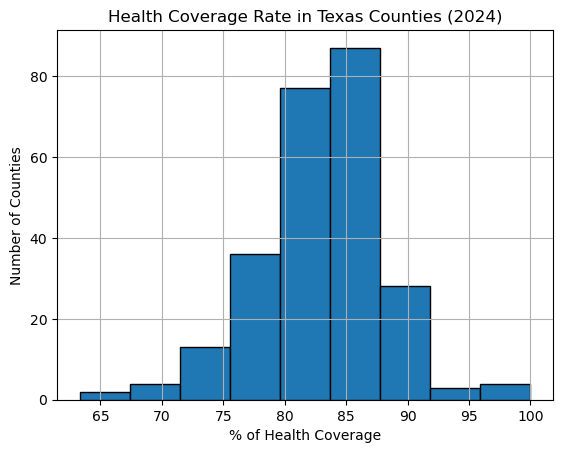


Saved to Exports Folder as PNG! ✅


In [26]:
comb_df["health_cov_rate"].hist(bins=9, edgecolor="black")
plt.title("Health Coverage Rate in Texas Counties (2024)")
plt.xlabel("% of Health Coverage")
plt.ylabel("Number of Counties")
plt.savefig(project_root/FOLDERS[2]/"distro_health.png", dpi=300, bbox_inches="tight")
plt.show()
print()
print("Saved to Exports Folder as PNG! ✅") 

**Comment:** The distribution of covered health insurance rates have slight left-skew. Majority of the counties have about 85% total coverage for their populations. 

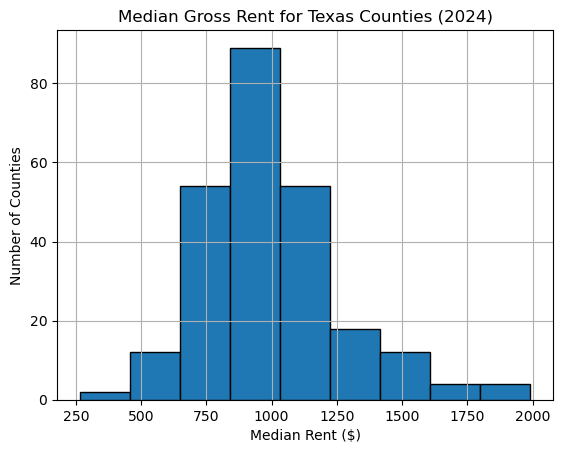


Saved to Exports Folder as PNG! ✅


In [27]:
comb_df["median_gross_rent"].hist(bins=9, edgecolor="black")
plt.title("Median Gross Rent for Texas Counties (2024)")
plt.xlabel("Median Rent ($)")
plt.ylabel("Number of Counties")
#Google Gemini adjusted how to save png file to export folder.
plt.savefig(project_root/FOLDERS[2]/"distro_rent.png", dpi=300, bbox_inches="tight")
plt.show()
print()
print("Saved to Exports Folder as PNG! ✅") 


**Comment:** The distribution of covered health insurance rates have slight right-skew. A majority of the counties have their median rent near 1000 dollars. 

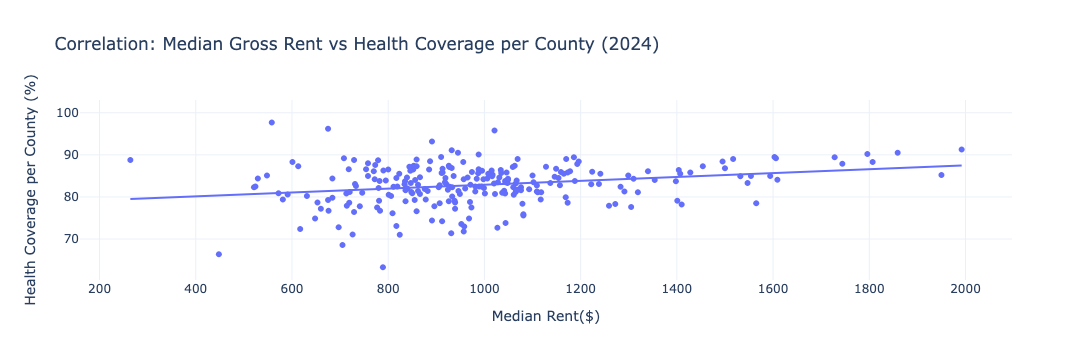


Saved to Exports Folder as html! ✅


In [28]:
clean_data_scatter = px.scatter(
    comb_df,
    x="median_gross_rent",
    y="health_cov_rate",
    trendline="ols",
    template="plotly_white",
    title="Correlation: Median Gross Rent vs Health Coverage per County (2024)",
    labels={
        "health_cov_rate": "Health Coverage per County (%)",
        "median_gross_rent": "Median Rent($)"
    }
)
        
clean_data_scatter.show()
#asked gemini how to save this file in exports
html_data = project_root/FOLDERS[2]/"rent_v_health.html"
clean_data_scatter.write_html(str(html_data))
print()
print("Saved to Exports Folder as html! ✅") 

**Notes After Initial Analysis:** After seeing both data sets applied on a scatter plot, the data would present a positive correlation between health coverage and renting costs per county. The correlation is slightly weaker than expected but it is still useful having it as a factor in my analysis. My hypothesis of higher renting costs and health insurance rates being higher together is somewhat probable. A majority of the counties are packed together with varying results from both variables.    

**PART 3: Regression**
- **Before Regression Run:** I suspect that I'd find a minimal effect from renting costs on the actual percentage of those covered.  

In [29]:
reg_health_rent = smf.ols("health_cov_rate ~ median_gross_rent", data=comb_df).fit()
reg_health_rent.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        health_cov_rate   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     17.63
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           3.75e-05
Time:                        13:21:24   Log-Likelihood:                -738.23
No. Observations:                 249   AIC:                             1480.
Df Residuals:                     247   BIC:                             1488.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            78.3116      1.132     69.203      0.000      76.083      80.540
median_gross_rent     0.0046      0.001      4.199      0.000       0.002       0.007
==============================================================================
Omnibus:                       17.049   Durbin-Watson:                   2.067
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               33.813
Skew:                          -0.338   Prob(JB):                     4.55e-08
Kurtosis:                       4.674   Cond. No.                     3.91e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.91e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Predicted Health Insurance Rate = 78.3116 + 0.0046** 

**Interpretation of OLS Results:** I have set the health insurance rate as my dependent variable and the median renting costs as my independent variable.   
- **Intercept(b0):** This means that if the Median Gross Rent was 0, the predicted Health Insurance Rate would be 78.3116.  
- **Median Gross Rent(b1):** This means that for every one dollar increase in the median rent, the Health Insurance Rate would increase by 0.0046. 
- **R-Squared:** The proportion of the variability in Health Insurance Rates that is explained using Median Rent. Which is 0.067, so 6.7% of the variation of Health rates can be explained with Rent costs. 
- **Is the Data useful?:** The P-Vaue of Median Gross Rent is less than the significance level of 0.05, so a null hypothesis is rejectable. The confidence interval of 95% does not include 0 even if the interval is very small. I believe there is some impact of rent to the rates of health insurance but it is very small.   
- **Other Notes:** The output from the regression above noted the there might be a strong multicollinearity between the X variables but there is only one. So, it could suggest that there may be other numerical problems with this process. 

In [30]:
results_df = pd.DataFrame({
    "Coefficient":  reg_health_rent.params.round(4),
    "HAC Std. Err": reg_health_rent.bse.round(4),
    "t-statistic":  reg_health_rent.tvalues.round(3),
    "p-value":      reg_health_rent.pvalues.round(4),
    "[95% CI Low]": reg_health_rent.conf_int()[0].round(4),
    "[95% CI High]": reg_health_rent.conf_int()[1].round(4),
})
results_df.to_csv("exports/ols_results.csv")
print("OLS results saved to exports/ols_results.csv! ✅")
print(f"\nR-squared:      {reg_health_rent.rsquared:.4f}")
print(f"Adj. R-squared: {reg_health_rent.rsquared_adj:.4f}")
print(f"N observations: {int(reg_health_rent.nobs)}")

OLS results saved to exports/ols_results.csv! ✅

R-squared:      0.0666
Adj. R-squared: 0.0628
N observations: 249


**AI DISCLOSURE:**
- AI Used: Google Gemini 3 Flash
- Codes were pasted into Gemini to check for syntax errors. **See below for specified add-ons from the model.**
- The AI model was used to clarify and troubleshoot errors with python scripts.
- Aided in renaming identifiers for easier readability in output.
- Aided in explaining python codes from past course lectures.
- Helped in troubleshooting how to pull in data that starts with "S" from ACS.
- Asked how to make a distribution table in python. Did not add data codes to make it for me.
- Any interpretation and decisions with the data implemented are all mine alone.
- **See # comments for specific AI notice on code cells**
| Code Added with Gemini |
|----------|
| Troubleshooted problems with def get_acs_state_data.|
|added if statement to account for data pulling for "B" and "S". Recommended "if r.status_code != 200:" to ensure data was pulled properly. |
| Clarified how to print a cleaner table and rename variables on "comb_df = merge_left.rename(columns={" |
|Adjusted saving distro charts with "plt.savefig(project_root/FOLDERS[2]"|
|Asked how to save scatter plot, "html_data = project_root/FOLDERS[2]/"rent_v_health.html"clean_data_scatter.write_html(str(html_data))"|

---
## Submission Checklist

Before submitting, confirm:

- [x] Notebook runs top-to-bottom without errors (`Kernel → Restart & Run All`)
- [x] `data_raw/fred_raw.csv` is present
- [x] `data_clean/fred_clean.csv` is present
- [x] All figures saved to `exports/`
- [x] `exports/ols_results.csv` is present
- [x] `midterm_report.md` (practitioner report) is included
- [x] No API keys are hard-coded in the notebook
- [x] AI disclosure is complete